Macierz korelacji Pearsona:
                    Price   Surface  Number_of_Rooms
Price            1.000000  0.029094         0.058906
Surface          0.029094  1.000000         0.759741
Number_of_Rooms  0.058906  0.759741         1.000000


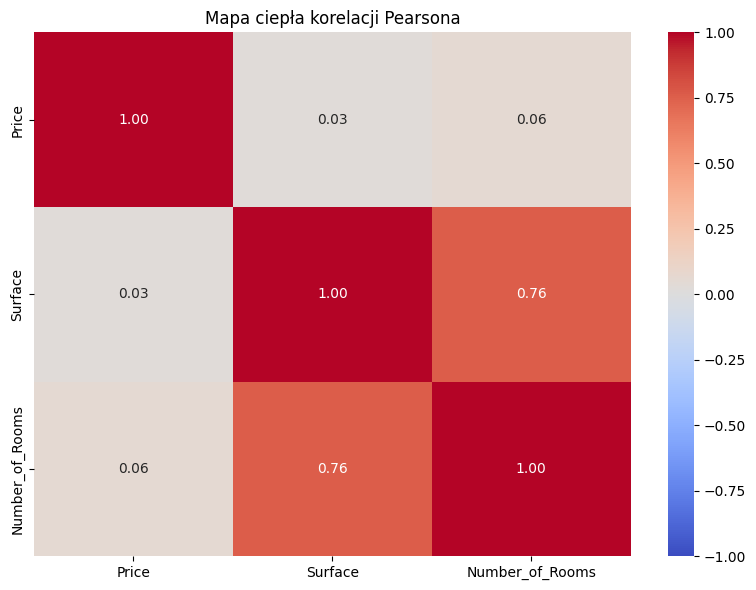

In [6]:
##zadanie 1

import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

df = pd.read_csv('Otodom_Flat_Listings.csv')
df['Number_of_Rooms'] = pd.to_numeric(df['Number_of_Rooms'], errors='coerce')

numeric_features = ['Price', 'Surface', 'Number_of_Rooms']
df_numeric = df[numeric_features]
corr_matrix = df_numeric.corr(method='pearson')
print("Macierz korelacji Pearsona:")
print(corr_matrix)

plt.figure(figsize=(8, 6))
sns.heatmap(corr_matrix,
            annot=True,
            cmap='coolwarm',
            fmt=".2f",
            vmin=-1, vmax=1)

plt.title('Mapa ciepła korelacji Pearsona')
plt.tight_layout()
plt.show()

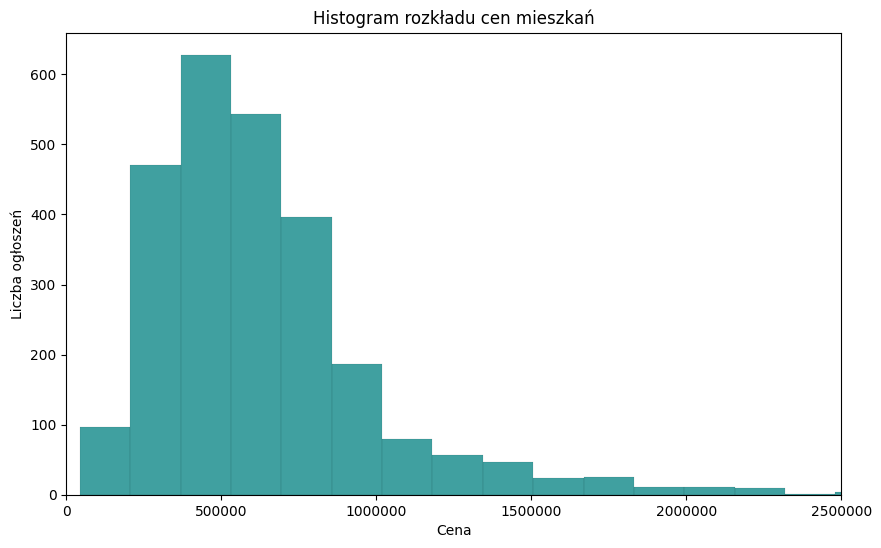

In [15]:
##zadanie 2

import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

df = pd.read_csv('Otodom_Flat_Listings.csv')

prices_cleaned = df['Price'].dropna()

plt.figure(figsize=(10, 6))
sns.histplot(prices_cleaned, bins=1000, color='teal')
plt.xlim(0, 2500000)
plt.title('Histogram rozkładu cen mieszkań')
plt.xlabel('Cena')
plt.ylabel('Liczba ogłoszeń')

plt.ticklabel_format(style='plain', axis='x')

plt.show()

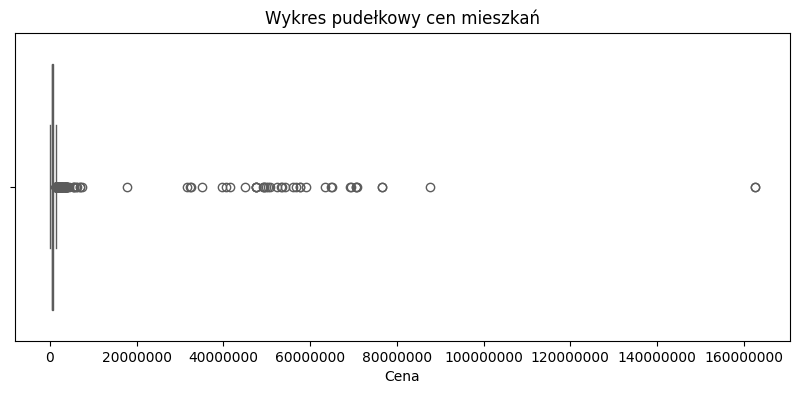

mamy wartosci odstajace
Liczba zidentyfikowanych wartości odstających: 200


,Title,Price,Location,Surface,Number_of_Rooms,Floor,Finishing_Condition,Heating,Parking_Space,Balcony_Garden_Terrace,Link,Voivodeship,City
1,Właściciel- Ludwiki DD - WIDOK NA ZIELEŃ - 2x gar,2499000.0,"ul. Ludwiki, Czyste, Wola, Warszawa, mazowieckie",105.00,4,2/8,do wykończenia,miejskie,garaż/miejsce parkingowe,balkon,https://www.otodom.pl/pl/oferta/wlasciciel-lud...,Mazowieckie,Warszawa
3,"Wyjątkowy, duży apartament z antresolą",2108000.0,"Mrzeżyno, Trzebiatów, gryficki, zachodniopomor...",78.30,3,4/4,do wykończenia,NaN,garaż/miejsce parkingowe,NaN,https://www.otodom.pl/pl/oferta/wyjatkowy-duzy...,Zachodniopomorskie,gryficki
19,Penthouse przy samej wodzie na dolinie 3 stawów,2923000.0,"ul. gen. Władysława Sikorskiego 41, Osiedle Pa...",121.80,3,8/8,do wykończenia,gazowe,garaż/miejsce parkingowe,"balkon, taras",https://www.otodom.pl/pl/oferta/penthouse-przy...,Śląskie,Katowice
59,Cała Kamienica na sprzedaż w Wągrowcu po remoncie,5990000.0,"ul. Kościuszki, Wągrowiec, wągrowiecki, wielko...",1847.77,więcej niż 10,1/4,NaN,NaN,garaż/miejsce parkingowe,"balkon, ogródek",https://www.otodom.pl/pl/oferta/cala-kamienica...,Wielkopolskie,wągrowiecki
61,"Apartament z widokiem na Wisłe, obok Elektrowni",2500000.0,"ul. Wybrzeże Kościuszkowskie, Powiśle, Śródmie...",78.00,2,1/5,do zamieszkania,NaN,garaż/miejsce parkingowe,taras,https://www.otodom.pl/pl/oferta/apartament-z-w...,Mazowieckie,Warszawa


In [32]:
##zadanie 3

import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

df = pd.read_csv('Otodom_Flat_Listings.csv')
df_clean = df.dropna(subset=['Price'])

plt.figure(figsize=(10, 4))
sns.boxplot(x=df_clean['Price'], color='mediumaquamarine')

plt.title('Wykres pudełkowy cen mieszkań')
plt.xlabel('Cena')
plt.ticklabel_format(style='plain', axis='x')
plt.show()

print("mamy wartosci odstajace")

Q1 = df_clean['Price'].quantile(0.25)
Q3 = df_clean['Price'].quantile(0.75)
IQR = Q3 - Q1

lower_bound = Q1 - 1.5 * IQR
upper_bound = Q3 + 1.5 * IQR

outlier_data = df_clean[(df_clean['Price'] < lower_bound) | (df_clean['Price'] > upper_bound)]

print(f"Liczba zidentyfikowanych wartości odstających: {len(outlier_data)}")

outlier_data.head()

Kwartyle dla cechy price_per_m2
Q1: 7583.33 PLN/m^2
Q2: 10354.04 PLN/m^2
Q3: 13922.71 PLN/m^2


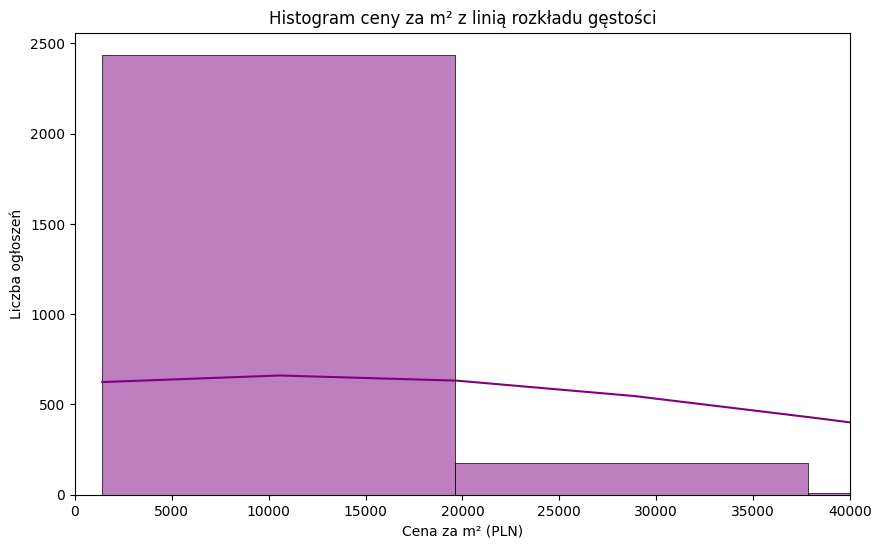

Wykres nie ma cech rozkladu normalnego, ponieważ nie jest symetryczny


In [24]:
##zadanie4

import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

df = pd.read_csv('Otodom_Flat_Listings.csv')

df_clean = df.dropna(subset=['Price', 'Surface']).copy()
df_clean = df_clean[df_clean['Surface'] > 0]

df_clean['price_per_m2'] = df_clean['Price'] / df_clean['Surface']

q1 = df_clean['price_per_m2'].quantile(0.25)
q2 = df_clean['price_per_m2'].quantile(0.50)
q3 = df_clean['price_per_m2'].quantile(0.75)

print("Kwartyle dla cechy price_per_m2")
print(f"Q1: {q1:.2f} PLN/m^2")
print(f"Q2: {q2:.2f} PLN/m^2")
print(f"Q3: {q3:.2f} PLN/m^2")

plt.figure(figsize=(10, 6))
sns.histplot(data=df_clean, x='price_per_m2', bins=100, kde=True, color='purple')
plt.xlim(0, 40000)
plt.title('Histogram ceny za m² z linią rozkładu gęstości')
plt.xlabel('Cena za m² (PLN)')
plt.ylabel('Liczba ogłoszeń')
plt.show()

print("Wykres nie ma cech rozkladu normalnego, ponieważ nie jest symetryczny")

Prawdopodobieństwo wyrzucenia dokładnie 7 orłów w 20 rzutach wynosi:
0.0739


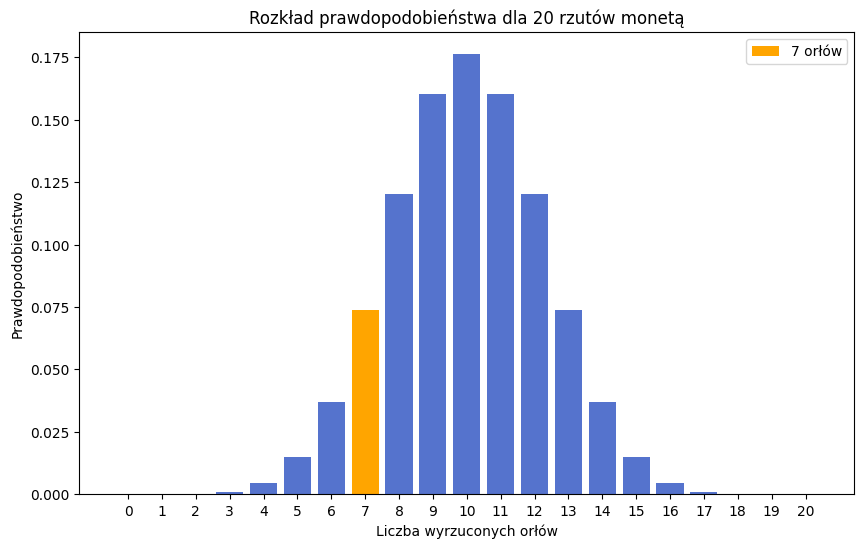

In [31]:
##zadanie 5
import math
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt

n = 20
p = 0.5
k = 7

prob_7_heads = math.comb(n, k) * (p**k) * ((1 - p)**(n - k))

print(f"Prawdopodobieństwo wyrzucenia dokładnie {k} orłów w {n} rzutach wynosi:")
print(f"{prob_7_heads:.4f}")

x_values = np.arange(0, n + 1)
y_probs = [math.comb(n, x) * (p**x) * ((1 - p)**(n - x)) for x in x_values]

plt.figure(figsize=(10, 6))
sns.barplot(x=x_values, y=y_probs, color='royalblue')
plt.bar(k, y_probs[k], color='orange', label=f'7 orłów')
plt.title('Rozkład prawdopodobieństwa dla 20 rzutów monetą')
plt.xlabel('Liczba wyrzuconych orłów')
plt.ylabel('Prawdopodobieństwo')
plt.legend()
plt.show()

In [29]:
##zadanie 6
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt

def simulate_dice_rolls(n_experiments, n_dice):
    rolls = np.random.randint(1, 7, size=(n_experiments, n_dice))
    sums = np.sum(rolls, axis=1)
    return sums.tolist()

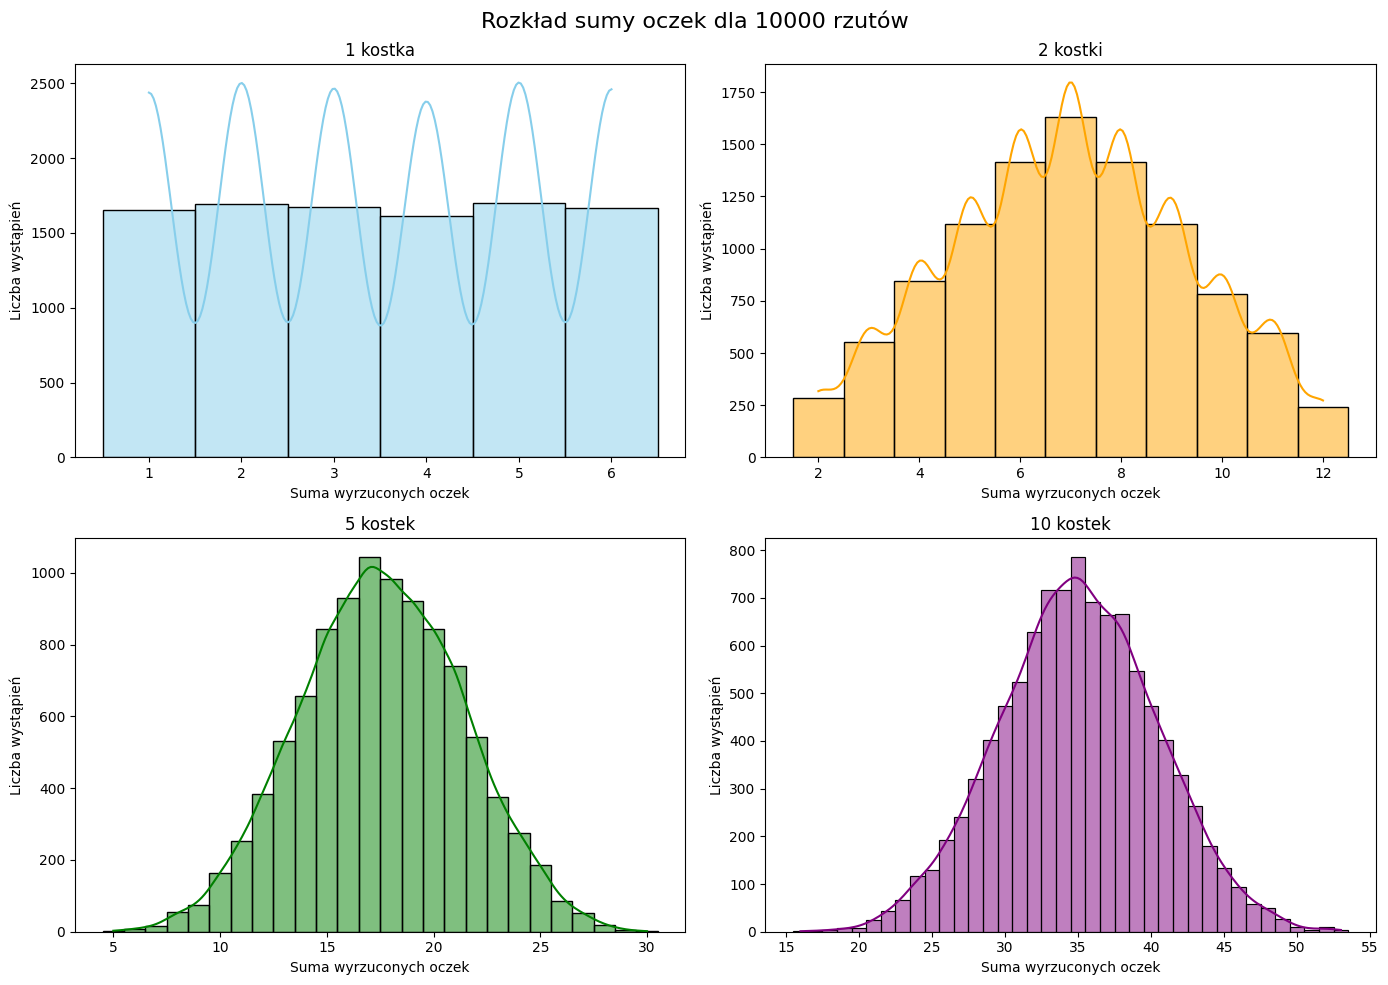

In [30]:
n_exp = 10000

sim_1_dice = simulate_dice_rolls(n_experiments=n_exp, n_dice=1)
sim_2_dice = simulate_dice_rolls(n_experiments=n_exp, n_dice=2)
sim_5_dice = simulate_dice_rolls(n_experiments=n_exp, n_dice=5)
sim_10_dice = simulate_dice_rolls(n_experiments=n_exp, n_dice=10)

fig, axes = plt.subplots(2, 2, figsize=(14, 10))
fig.suptitle(f'Rozkład sumy oczek dla {n_exp} rzutów', fontsize=16)

sns.histplot(sim_1_dice, kde=True, discrete=True, color='skyblue', ax=axes[0, 0])
axes[0, 0].set_title('1 kostka')

sns.histplot(sim_2_dice, kde=True, discrete=True, color='orange', ax=axes[0, 1])
axes[0, 1].set_title('2 kostki')

sns.histplot(sim_5_dice, kde=True, discrete=True, color='green', ax=axes[1, 0])
axes[1, 0].set_title('5 kostek')

sns.histplot(sim_10_dice, kde=True, discrete=True, color='purple', ax=axes[1, 1])
axes[1, 1].set_title('10 kostek')

for ax in axes.flat:
    ax.set_xlabel('Suma wyrzuconych oczek')
    ax.set_ylabel('Liczba wystąpień')

plt.tight_layout()
plt.show()